<a href="https://colab.research.google.com/github/SakshyamSingB/AI-ML/blob/main/NLP_SakshyamSingBhandari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 — Part III: Language Task
## Book Review Sentiment Classification using SimpleRNN, LSTM and Pretrained Word Embeddings

**Dataset:** Book Review Dataset assigned by instructor  
**Task:** Text classification / sentiment analysis  
**Models:**
1. SimpleRNN with trainable Embedding layer
2. LSTM with trainable Embedding layer
3. LSTM with pretrained GloVe / Word2Vec-style embeddings



## 0. Install and import libraries

This cell also fixes the earlier `contractions` problem. If the package install fails, the notebook still works using a fallback contraction expander.

In [ ]:
!pip -q install --upgrade pip setuptools wheel
!pip -q install wordcloud nltk gensim contractions || true

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 65.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
import os, re, random, time, string, json, pickle, zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_style('whitegrid')
except Exception:
    sns = None

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
try:
    import contractions
    def expand_contractions(text):
        return contractions.fix(text)
    print('Using contractions package.')
except Exception:
    print('contractions package unavailable; using fallback dictionary.')
    CONTRACTION_MAP = {
        "ain't": "am not", "aren't": "are not", "can't": "cannot", "could've": "could have",
        "couldn't": "could not", "didn't": "did not", "doesn't": "does not", "don't": "do not",
        "hadn't": "had not", "hasn't": "has not", "haven't": "have not", "he'd": "he would",
        "he'll": "he will", "he's": "he is", "i'd": "i would", "i'll": "i will", "i'm": "i am",
        "i've": "i have", "isn't": "is not", "it's": "it is", "let's": "let us", "mustn't": "must not",
        "shan't": "shall not", "she'd": "she would", "she'll": "she will", "she's": "she is",
        "should've": "should have", "shouldn't": "should not", "that's": "that is", "there's": "there is",
        "they'd": "they would", "they'll": "they will", "they're": "they are", "they've": "they have",
        "wasn't": "was not", "we'd": "we would", "we'll": "we will", "we're": "we are", "we've": "we have",
        "weren't": "were not", "what's": "what is", "won't": "will not", "would've": "would have",
        "wouldn't": "would not", "you'd": "you would", "you'll": "you will", "you're": "you are",
        "you've": "you have", "n't": " not", "'re": " are", "'s": " is", "'d": " would",
        "'ll": " will", "'ve": " have", "'m": " am"
    }
    def expand_contractions(text):
        text = str(text)
        for short, full in CONTRACTION_MAP.items():
            text = re.sub(re.escape(short), full, text, flags=re.IGNORECASE)
        return text

print(expand_contractions("I don't think it's bad."))

Using contractions package.
I do not think it is bad.


## 1. Load the dataset



In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Not running in Colab or Drive unavailable.')

ZIP_PATH = '/content/drive/MyDrive/1. Book Review Dataset-20260506T103209Z-3-001.zip'

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f'ZIP file not found: {ZIP_PATH}. Update ZIP_PATH to your dataset location.')

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    names = z.namelist()
    print('Files inside ZIP:')
    for n in names:
        print(' -', n)
    csv_files = [n for n in names if n.lower().endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError('No CSV file found inside the ZIP.')
    csv_name = csv_files[0]
    print('\nLoading:', csv_name)
    with z.open(csv_name) as f:
        df = pd.read_csv(f)

df = df.drop(columns=[c for c in df.columns if str(c).startswith('Unnamed')], errors='ignore')
print('Shape:', df.shape)
df.head()

Mounted at /content/drive
Files inside ZIP:
 - 1. Book Review Dataset/1. Description - Book Review Dataset.txt
 - 1. Book Review Dataset/Book_review.csv

Loading: 1. Book Review Dataset/Book_review.csv
Shape: (12000, 3)


,rating,reviewText,summary
0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [ ]:
print('Columns:', list(df.columns))
df.info()

Columns: ['rating', 'reviewText', 'summary']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rating      12000 non-null  int64 
 1   reviewText  12000 non-null  object
 2   summary     11998 non-null  object
dtypes: int64(1), object(2)
memory usage: 281.4+ KB


## 2. Create sentiment labels from book ratings



In [ ]:
text_candidates = ['reviewText', 'review_text', 'review', 'text', 'Review', 'content']
summary_candidates = ['summary', 'Summary', 'title', 'Title']
label_candidates = ['rating', 'Rating', 'overall', 'score', 'stars']

TEXT_COL = next((c for c in text_candidates if c in df.columns), None)
SUMMARY_COL = next((c for c in summary_candidates if c in df.columns), None)
RATING_COL = next((c for c in label_candidates if c in df.columns), None)

if TEXT_COL is None:
    raise ValueError('Could not find review text column. Available columns: ' + str(list(df.columns)))
if RATING_COL is None:
    raise ValueError('Could not find rating/label column. Available columns: ' + str(list(df.columns)))

print('TEXT_COL:', TEXT_COL)
print('SUMMARY_COL:', SUMMARY_COL)
print('RATING_COL:', RATING_COL)

df = df.dropna(subset=[TEXT_COL, RATING_COL]).copy()
df[TEXT_COL] = df[TEXT_COL].astype(str)

if SUMMARY_COL is not None:
    df[SUMMARY_COL] = df[SUMMARY_COL].fillna('').astype(str)
    df['raw_text'] = (df[SUMMARY_COL] + '. ' + df[TEXT_COL]).str.strip()
else:
    df['raw_text'] = df[TEXT_COL]

df[RATING_COL] = pd.to_numeric(df[RATING_COL], errors='coerce')
df = df.dropna(subset=[RATING_COL]).copy()
df[RATING_COL] = df[RATING_COL].astype(int)

def rating_to_sentiment(r):
    if r <= 2:
        return 0
    elif r == 3:
        return 1
    else:
        return 2

df['sentiment_id'] = df[RATING_COL].apply(rating_to_sentiment)
df['sentiment'] = df['sentiment_id'].map({0: 'Negative', 1: 'Neutral', 2: 'Positive'})
df = df[df['raw_text'].str.strip() != ''].reset_index(drop=True)

df[[RATING_COL, 'sentiment', 'raw_text']].head()

TEXT_COL: reviewText
SUMMARY_COL: summary
RATING_COL: rating


,rating,sentiment,raw_text
0,5,Positive,50 + years ago.... This book was the very firs...
1,1,Negative,Boring! Boring! Boring!. When I read the descr...
2,5,Positive,Wiggleliscious/new toy ready/!!. I just had to...
3,5,Positive,Very good read.. I don't normally buy 'mystery...
4,5,Positive,Great Story!. This isn't the kind of book I no...


Original rating distribution:
rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64

Mapped sentiment distribution:
sentiment
Negative    4000
Neutral     2000
Positive    6000
Name: count, dtype: int64


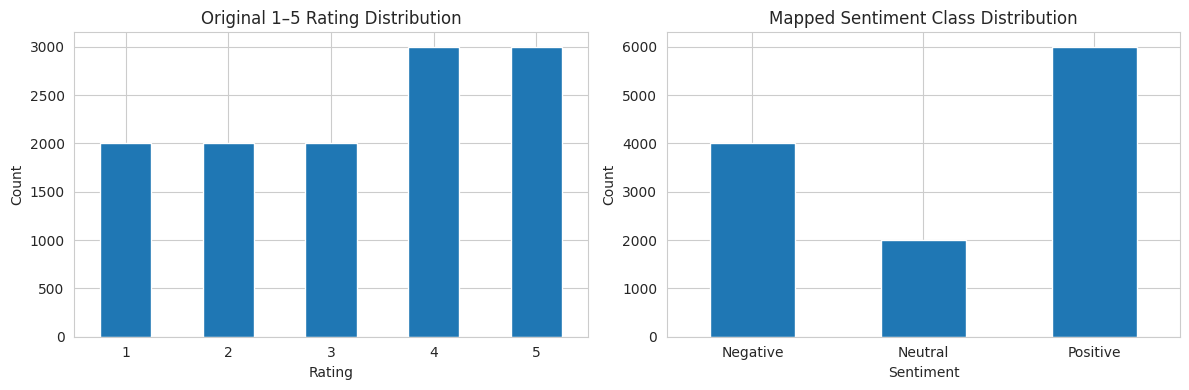

In [ ]:
rating_counts = df[RATING_COL].value_counts().sort_index()
sent_counts = df['sentiment'].value_counts().reindex(['Negative', 'Neutral', 'Positive'])

print('Original rating distribution:')
print(rating_counts)
print('\nMapped sentiment distribution:')
print(sent_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rating_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Original 1–5 Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

sent_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Mapped Sentiment Class Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

count    12000.000000
mean       113.217667
std        126.802735
min          3.000000
25%         35.000000
50%         65.000000
75%        139.000000
max       2161.000000
Name: raw_word_count, dtype: float64


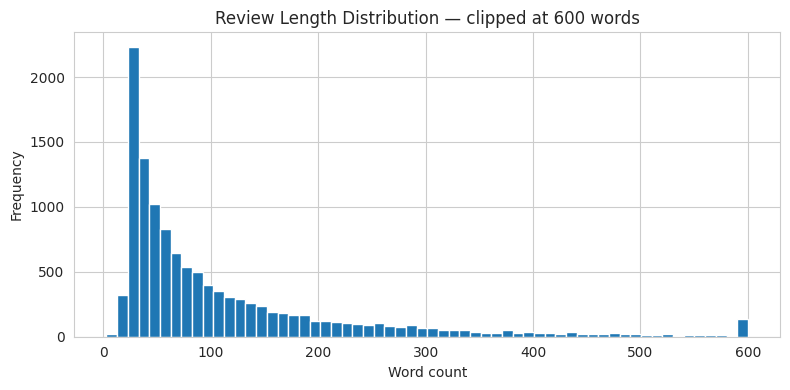

In [ ]:
df['raw_word_count'] = df['raw_text'].str.split().str.len()
print(df['raw_word_count'].describe())

plt.figure(figsize=(8, 4))
plt.hist(df['raw_word_count'].clip(upper=600), bins=60)
plt.title('Review Length Distribution — clipped at 600 words')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Text preprocessing



In [ ]:
BASE_STOPWORDS = set(stopwords.words('english'))
NEGATION_WORDS = {
    'no', 'nor', 'not', 'never', 'cannot', 'cant',
    'don', "don't", 'didn', "didn't", 'doesn', "doesn't",
    'isn', "isn't", 'aren', "aren't", 'wasn', "wasn't", 'weren', "weren't",
    'couldn', "couldn't", 'shouldn', "shouldn't", 'wouldn', "wouldn't", 'won', "won't"
}
STOPWORDS = BASE_STOPWORDS - NEGATION_WORDS
LEMMA = WordNetLemmatizer()

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
NUM_RE = re.compile(r'\d+')
PUNCT_RE = re.compile(f'[{re.escape(string.punctuation)}]')
SPACE_RE = re.compile(r'\s+')

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = expand_contractions(text)
    text = URL_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text)
    text = text.replace('#', ' ')
    text = NUM_RE.sub(' ', text)
    text = PUNCT_RE.sub(' ', text)
    text = SPACE_RE.sub(' ', text).strip()
    tokens = []
    for word in text.split():
        if word in STOPWORDS or len(word) <= 1:
            continue
        tokens.append(LEMMA.lemmatize(word))
    return ' '.join(tokens)

example = "I don't think this book is bad! #Amazing https://example.com"
print('Before:', example)
print('After :', clean_text(example))

Before: I don't think this book is bad! #Amazing https://example.com
After : not think book bad amazing


In [ ]:
df['clean_text'] = df['raw_text'].apply(clean_text)
df['clean_word_count'] = df['clean_text'].str.split().str.len()
df = df[df['clean_word_count'] >= 3].reset_index(drop=True)
print('Rows after dropping near-empty cleaned texts:', len(df))
df[[RATING_COL, 'sentiment', 'raw_text', 'clean_text']].head(3)

Rows after dropping near-empty cleaned texts: 11999


,rating,sentiment,raw_text,clean_text
0,5,Positive,50 + years ago.... This book was the very firs...,year ago book first bookmobile book bought sch...
1,1,Negative,Boring! Boring! Boring!. When I read the descr...,boring boring boring read description book cou...
2,5,Positive,Wiggleliscious/new toy ready/!!. I just had to...,wiggleliscious new toy ready edit review book ...


## 4. Visualise cleaned text

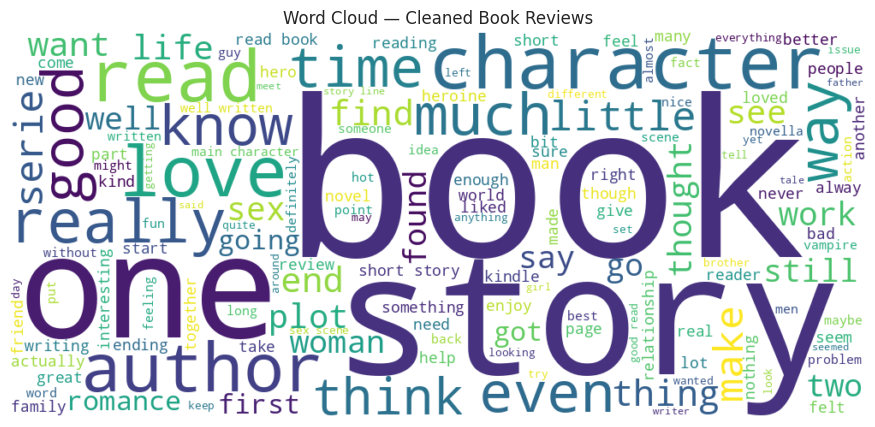

In [ ]:
all_text = ' '.join(df['clean_text'].tolist())
wc = WordCloud(width=1000, height=450, background_color='white', max_words=150).generate(all_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Cleaned Book Reviews')
plt.show()

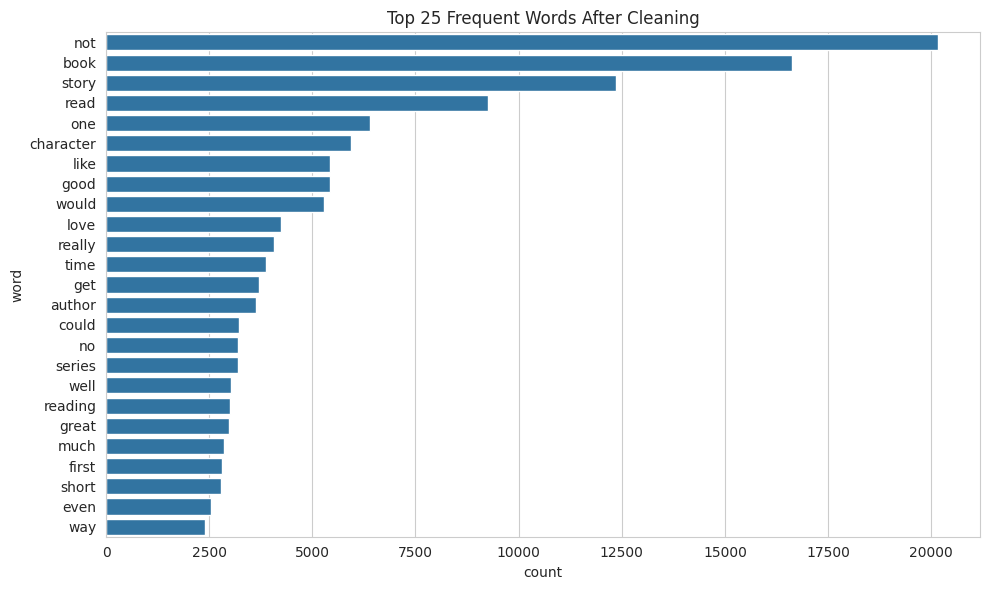

In [ ]:
freq = Counter(all_text.split()).most_common(25)
freq_df = pd.DataFrame(freq, columns=['word', 'count'])
plt.figure(figsize=(10, 6))
if sns is not None:
    sns.barplot(data=freq_df, y='word', x='count')
else:
    plt.barh(freq_df['word'], freq_df['count'])
plt.title('Top 25 Frequent Words After Cleaning')
plt.tight_layout()
plt.show()

## 5. Tokenisation, padding and split

The 80/20 train-test split is used.

In [ ]:
NUM_CLASSES = 3
TARGET_NAMES = ['Negative', 'Neutral', 'Positive']

texts = df['clean_text'].values
y = df['sentiment_id'].values
raw_texts = df['raw_text'].values

X_train_txt, X_test_txt, y_train, y_test, raw_train, raw_test = train_test_split(
    texts, y, raw_texts, test_size=0.20, stratify=y, random_state=SEED
)

X_train_txt, X_val_txt, y_train, y_val, raw_train, raw_val = train_test_split(
    X_train_txt, y_train, raw_train, test_size=0.10, stratify=y_train, random_state=SEED
)

print('Train:', len(X_train_txt))
print('Validation:', len(X_val_txt))
print('Test:', len(X_test_txt))

Train: 8639
Validation: 960
Test: 2400


In [ ]:
VOCAB_SIZE = 15000
OOV_TOKEN = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_txt)

X_train_seq = tokenizer.texts_to_sequences(X_train_txt)
X_val_seq = tokenizer.texts_to_sequences(X_val_txt)
X_test_seq = tokenizer.texts_to_sequences(X_test_txt)

seq_lens = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(seq_lens, 90))
MAX_LEN = max(20, min(MAX_LEN, 250))

print('Actual vocabulary size:', len(tokenizer.word_index) + 1)
print('Capped vocabulary size:', min(VOCAB_SIZE, len(tokenizer.word_index) + 1))
print('MAX_LEN using 90th percentile:', MAX_LEN)

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print('X_train:', X_train.shape)
print('X_val  :', X_val.shape)
print('X_test :', X_test.shape)

Actual vocabulary size: 23099
Capped vocabulary size: 15000
MAX_LEN using 90th percentile: 135
X_train: (8639, 135)
X_val  : (960, 135)
X_test : (2400, 135)


In [ ]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print('Class weights:', class_weights)

Class weights: {np.int64(0): np.float64(0.9998842592592593), np.int64(1): np.float64(1.9997685185185186), np.int64(2): np.float64(0.6667438450258547)}


## 6. Build the three required models

In [ ]:
EPOCHS = 25
BATCH_SIZE = 64
EMBED_DIM = 128

def make_callbacks(name):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
        callbacks.ModelCheckpoint(filepath=f'{name}.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
    ]

def compile_model(model, lr=5e-4):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

### Model 1 — SimpleRNN with trainable Embedding

In [ ]:
def build_simple_rnn():
    model = keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
        layers.SpatialDropout1D(0.25),
        layers.SimpleRNN(64, return_sequences=True),
        layers.GlobalMaxPooling1D(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='SimpleRNN_trainable_embedding')
    return compile_model(model, lr=5e-4)

rnn_model = build_simple_rnn()
rnn_model.summary()

Model: "SimpleRNN_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 135, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 135, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 135, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,936,707 (7.39 MB)

 Trainable params: 1,936,707 (7.39 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM with trainable Embedding

In [ ]:
def build_lstm_trainable():
    model = keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
        layers.SpatialDropout1D(0.25),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25)),
        layers.GlobalMaxPooling1D(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='BiLSTM_trainable_embedding')
    return compile_model(model, lr=5e-4)

lstm_model = build_lstm_trainable()
lstm_model.summary()

Model: "BiLSTM_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 135, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 135, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 135, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,027,267 (7.73 MB)

 Trainable params: 2,027,267 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM with pretrained GloVe embeddings



In [ ]:
import gensim.downloader as api

print('Loading pretrained GloVe embeddings. First run may take a few minutes...')
embedding_model = api.load('glove-wiki-gigaword-50')
print('Loaded vector size:', embedding_model.vector_size)

Loading pretrained GloVe embeddings. First run may take a few minutes...
[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded vector size: 50


In [ ]:
EMBED_DIM_PRE = embedding_model.vector_size
word_index = tokenizer.word_index
vocab_size_eff = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size_eff, EMBED_DIM_PRE), dtype='float32')
hits = 0
misses = 0

for word, idx in word_index.items():
    if idx >= vocab_size_eff:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        hits += 1
    else:
        misses += 1

coverage = 100 * hits / max(1, hits + misses)
print(f'Embedding coverage: {hits:,} hits / {hits + misses:,} words = {coverage:.2f}%')

Embedding coverage: 14,165 hits / 14,999 words = 94.44%


In [ ]:
def build_lstm_pretrained():
    model = keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=vocab_size_eff, output_dim=EMBED_DIM_PRE, weights=[embedding_matrix], trainable=True),
        layers.SpatialDropout1D(0.20),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25)),
        layers.GlobalMaxPooling1D(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='BiLSTM_pretrained_GloVe')
    return compile_model(model, lr=3e-4)

glove_model = build_lstm_pretrained()
glove_model.summary()

Model: "BiLSTM_pretrained_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 135, 50)        │       750,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 135, 50)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 135, 128)       │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 817,331 (3.12 MB)

 Trainable params: 817,331 (3.12 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the models

In [ ]:
def train_model(model, name):
    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(name),
        class_weight=class_weights,
        verbose=2
    )
    train_time = time.time() - start
    print(f'{name} training time: {train_time:.2f} seconds')
    return history, train_time

hist_rnn, time_rnn = train_model(rnn_model, 'simple_rnn_best')
hist_lstm, time_lstm = train_model(lstm_model, 'lstm_trainable_best')
hist_glove, time_glove = train_model(glove_model, 'lstm_glove_best')

Epoch 1/25
135/135 - 11s - 81ms/step - accuracy: 0.3426 - loss: 1.1086 - val_accuracy: 0.3948 - val_loss: 1.1027 - learning_rate: 5.0000e-04
Epoch 2/25
135/135 - 2s - 15ms/step - accuracy: 0.5371 - loss: 1.0193 - val_accuracy: 0.6156 - val_loss: 0.9277 - learning_rate: 5.0000e-04
Epoch 3/25
135/135 - 2s - 14ms/step - accuracy: 0.6696 - loss: 0.8985 - val_accuracy: 0.6979 - val_loss: 0.8338 - learning_rate: 5.0000e-04
Epoch 4/25
135/135 - 2s - 13ms/step - accuracy: 0.7441 - loss: 0.7774 - val_accuracy: 0.6802 - val_loss: 0.8394 - learning_rate: 5.0000e-04
Epoch 5/25
135/135 - 2s - 15ms/step - accuracy: 0.7617 - loss: 0.7037 - val_accuracy: 0.7177 - val_loss: 0.7639 - learning_rate: 5.0000e-04
Epoch 6/25
135/135 - 2s - 15ms/step - accuracy: 0.8070 - loss: 0.5791 - val_accuracy: 0.6875 - val_loss: 0.7785 - learning_rate: 5.0000e-04
Epoch 7/25

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
135/135 - 2s - 14ms/step - accuracy: 0.8582 - loss: 0.4339 - val_accura

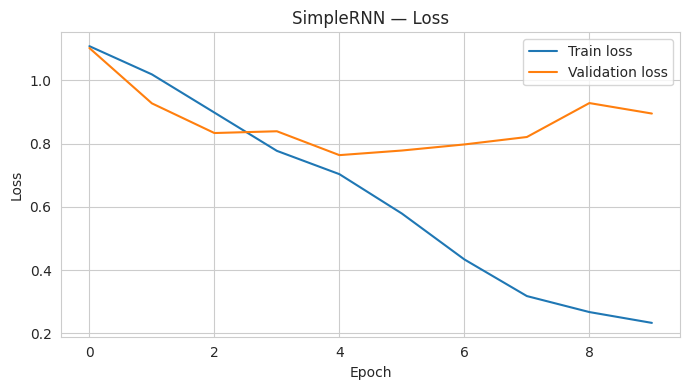

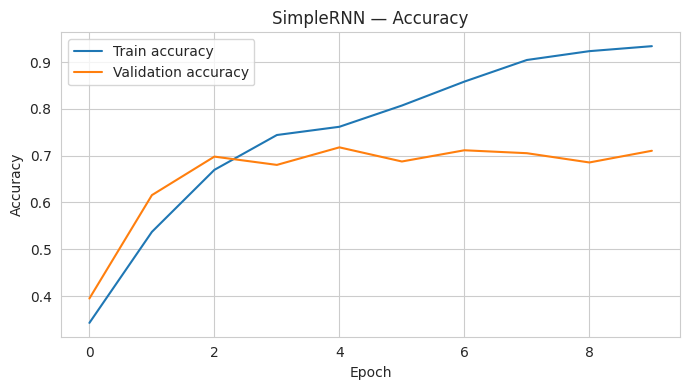

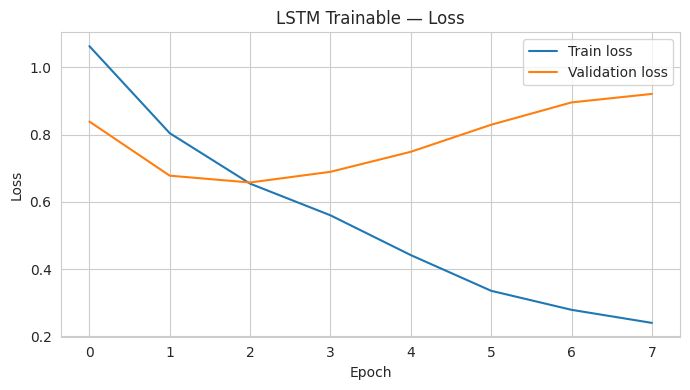

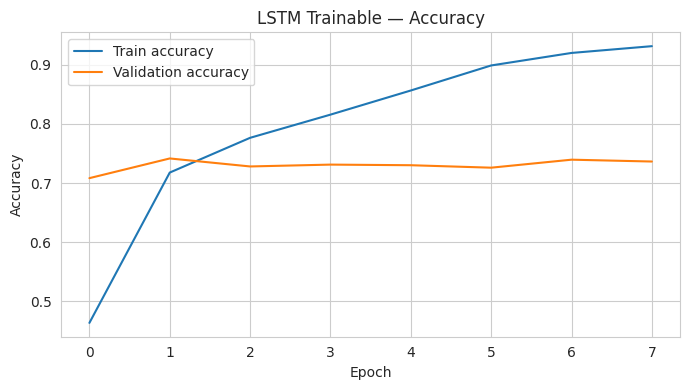

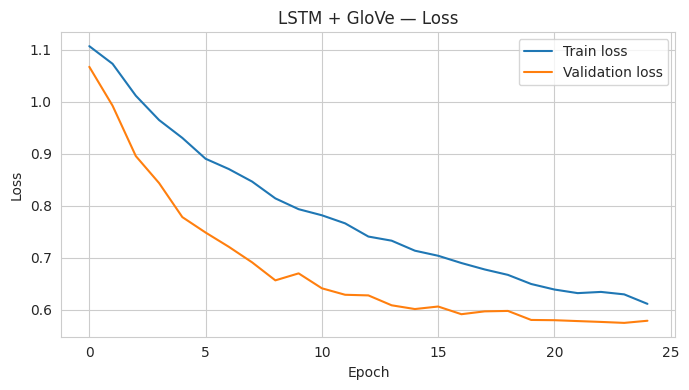

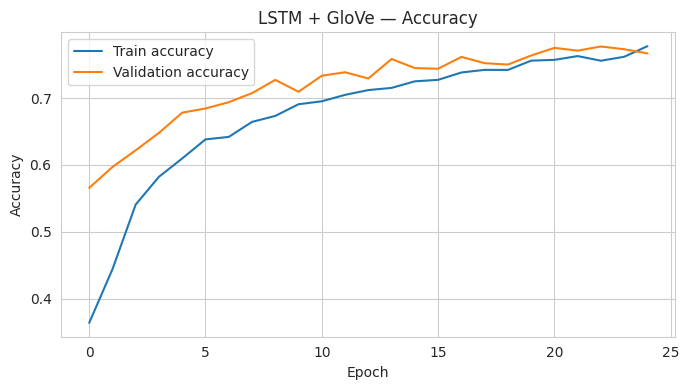

In [ ]:
def plot_history(history, name):
    hist = history.history
    plt.figure(figsize=(7, 4))
    plt.plot(hist['loss'], label='Train loss')
    plt.plot(hist['val_loss'], label='Validation loss')
    plt.title(f'{name} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist['accuracy'], label='Train accuracy')
    plt.plot(hist['val_accuracy'], label='Validation accuracy')
    plt.title(f'{name} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(hist_rnn, 'SimpleRNN')
plot_history(hist_lstm, 'LSTM Trainable')
plot_history(hist_glove, 'LSTM + GloVe')

## 8. Evaluation — accuracy, confusion matrix and classification report

===== SimpleRNN =====
Test accuracy : 0.7033
Precision     : 0.7029
Recall        : 0.7033
F1-score      : 0.7030
Train time(s) : 28.17

Classification report:
              precision    recall  f1-score   support

    Negative       0.72      0.74      0.73       800
     Neutral       0.36      0.35      0.35       400
    Positive       0.81      0.79      0.80      1200

    accuracy                           0.70      2400
   macro avg       0.63      0.63      0.63      2400
weighted avg       0.70      0.70      0.70      2400



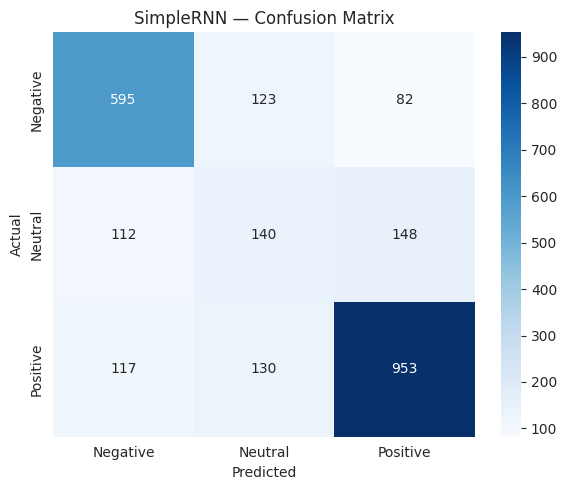

===== LSTM Trainable =====
Test accuracy : 0.7208
Precision     : 0.7538
Recall        : 0.7208
F1-score      : 0.7340
Train time(s) : 30.70

Classification report:
              precision    recall  f1-score   support

    Negative       0.84      0.71      0.77       800
     Neutral       0.31      0.42      0.35       400
    Positive       0.85      0.83      0.84      1200

    accuracy                           0.72      2400
   macro avg       0.66      0.65      0.65      2400
weighted avg       0.75      0.72      0.73      2400



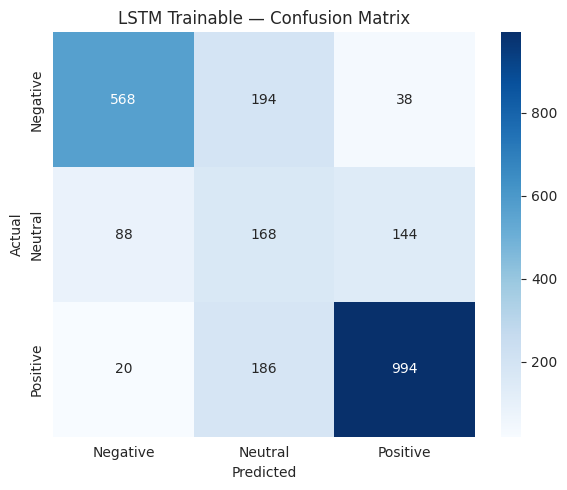

===== LSTM + Pretrained GloVe =====
Test accuracy : 0.7529
Precision     : 0.7701
Recall        : 0.7529
F1-score      : 0.7604
Train time(s) : 73.61

Classification report:
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80       800
     Neutral       0.39      0.48      0.43       400
    Positive       0.87      0.82      0.84      1200

    accuracy                           0.75      2400
   macro avg       0.69      0.70      0.69      2400
weighted avg       0.77      0.75      0.76      2400



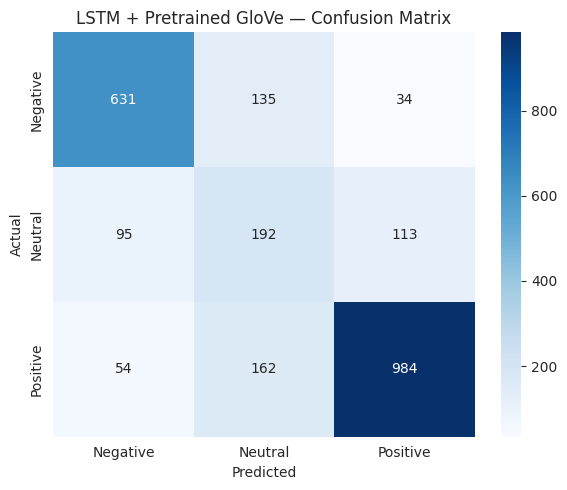

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,train_time_seconds
2,LSTM + Pretrained GloVe,0.752917,0.770111,0.752917,0.760372,73.605056
1,LSTM Trainable,0.720833,0.753793,0.720833,0.733971,30.703498
0,SimpleRNN,0.703333,0.702858,0.703333,0.703017,28.170219


In [ ]:
def evaluate_model(model, name, train_time):
    probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

    print(f'===== {name} =====')
    print(f'Test accuracy : {acc:.4f}')
    print(f'Precision     : {precision:.4f}')
    print(f'Recall        : {recall:.4f}')
    print(f'F1-score      : {f1:.4f}')
    print(f'Train time(s) : {train_time:.2f}')
    print('\nClassification report:')
    print(classification_report(y_test, y_pred, target_names=TARGET_NAMES, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    if sns is not None:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    else:
        plt.imshow(cm)
        plt.colorbar()
        plt.xticks(range(NUM_CLASSES), TARGET_NAMES)
        plt.yticks(range(NUM_CLASSES), TARGET_NAMES)
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return {'model': name, 'accuracy': acc, 'precision_weighted': precision, 'recall_weighted': recall, 'f1_weighted': f1, 'train_time_seconds': train_time}, y_pred, probs

res_rnn, pred_rnn, prob_rnn = evaluate_model(rnn_model, 'SimpleRNN', time_rnn)
res_lstm, pred_lstm, prob_lstm = evaluate_model(lstm_model, 'LSTM Trainable', time_lstm)
res_glove, pred_glove, prob_glove = evaluate_model(glove_model, 'LSTM + Pretrained GloVe', time_glove)

results_df = pd.DataFrame([res_rnn, res_lstm, res_glove]).sort_values('f1_weighted', ascending=False)
results_df

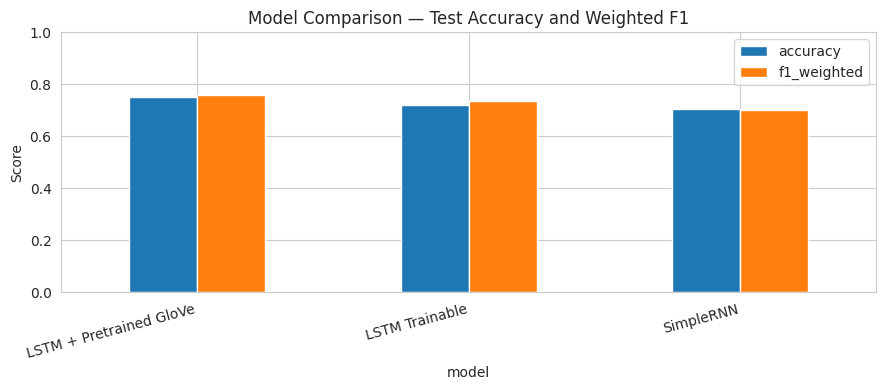

In [ ]:
results_df.to_csv('model_results.csv', index=False)

plt.figure(figsize=(9, 4))
plot_df = results_df.set_index('model')[['accuracy', 'f1_weighted']]
plot_df.plot(kind='bar', ax=plt.gca())
plt.ylim(0, 1)
plt.title('Model Comparison — Test Accuracy and Weighted F1')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 9. Error analysis — misclassified examples

In [ ]:
best_name = results_df.iloc[0]['model']
if best_name == 'SimpleRNN':
    best_model, best_pred, best_prob = rnn_model, pred_rnn, prob_rnn
elif best_name == 'LSTM Trainable':
    best_model, best_pred, best_prob = lstm_model, pred_lstm, prob_lstm
else:
    best_model, best_pred, best_prob = glove_model, pred_glove, prob_glove

print('Best model:', best_name)

mis_idx = np.where(best_pred != y_test)[0]
print(f'Misclassified examples: {len(mis_idx)} / {len(y_test)}')

if len(mis_idx) > 0:
    sample_n = min(5, len(mis_idx))
    chosen = np.random.RandomState(SEED).choice(mis_idx, size=sample_n, replace=False)
    for idx in chosen:
        print('=' * 100)
        print('Actual   :', TARGET_NAMES[y_test[idx]])
        print('Predicted:', TARGET_NAMES[best_pred[idx]])
        print('Confidence:', float(np.max(best_prob[idx])))
        print('Review:')
        print(str(raw_test[idx])[:900])

Best model: LSTM + Pretrained GloVe
Misclassified examples: 593 / 2400
Actual   : Neutral
Predicted: Negative
Confidence: 0.8648666739463806
Review:
Edit me please. There are some Sections where it looks like random bits have been cut and pasted willy nilly in the middle of conversations, turning it into gibberish. Feels like it was efited by someone with their eyes closed. Is this the correct version?
Actual   : Negative
Predicted: Positive
Confidence: 0.8399844765663147
Review:
The  Christian Novel Collection. The first collection of its type this book holds four stories. At the Back of the North Wind, the first is a story of goodness. Ben Hur is a great classic. It is second in the series.What Would Jesus Do highlights personal choices and how they effect life.The last story is the story it good versus evil.aptly named the The Man Who Was Thursday.  Very intriguing hard to read. Dottiek
Actual   : Positive
Predicted: Neutral
Confidence: 0.5215572714805603
Review:
Great little story.

### Error analysis notes for report

This section examines examples where the model predicted the wrong sentiment class. Looking at incorrect predictions helps identify possible reasons for errors, such as mixed sentiment in the same review, short reviews with limited context, or neutral reviews that contain both positive and negative words. This supports the discussion section of the report by showing that the model’s weaknesses were analysed rather than only reporting final scores.

## 10. Save model artefacts

In [ ]:
best_model.save('best_sentiment_model.keras')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('config.json', 'w') as f:
    json.dump({'max_len': int(MAX_LEN), 'num_classes': int(NUM_CLASSES), 'target_names': TARGET_NAMES}, f)

print('Saved files:')
print('- best_sentiment_model.keras')
print('- tokenizer.pkl')
print('- config.json')
print('- model_results.csv')

Saved files:
- best_sentiment_model.keras
- tokenizer.pkl
- config.json
- model_results.csv


## 11. Real-time prediction function

In [ ]:
def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = best_model.predict(padded, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    return {
        'cleaned_text': cleaned,
        'predicted_class': TARGET_NAMES[pred_id],
        'confidence': float(np.max(probs)),
        'probabilities': {TARGET_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}
    }

predict_sentiment('This book was excellent. I loved the story and the characters were amazing.')

{'cleaned_text': 'book excellent loved story character amazing',
 'predicted_class': 'Positive',
 'confidence': 0.9868077635765076,
 'probabilities': {'Negative': 0.00033981530577875674,
  'Neutral': 0.01285246666520834,
  'Positive': 0.9868077635765076}}